# Notebook 05: Station Validation

This notebook validates bias-corrected gridded precipitation products against
independent weather station observations from BMKG (Indonesian Meteorological
Agency). Station data provides a truly independent ground-truth test using
point-scale daily precipitation measurements that were **not** used in the
correction pipeline.

**What this notebook does**
- Extracts gridded product values at 171+ BMKG station locations
- Computes 31 per-station verification metrics (continuous, categorical, distributional)
- **WMO multi-threshold categorical verification** (POD, FAR, CSI, FBI, ETS, HSS, HK)
- Regional analysis by main island and province
- On-demand per-station scatter plots and time series
- Saves all results as CSV for further analysis

**Reproducibility note**
- Colab-specific steps (Drive mounting, `pip install`) are explicitly marked.
- Outside Colab, skip those sections and keep the same workflow logic unchanged.
- To port the workflow to a new environment, update only `config.yml`.

---


::: {.callout-note title="What you'll do in this notebook"}
nb03 and nb04 scored the products against **CPC** - but CPC is the *training reference*, so that is a partly circular test. This notebook scores against **BMKG weather stations**, which are **not** in the CPC pipeline. This is the genuinely independent check.

**The mental model**: extract the corrected grid at each station's nearest pixel, pair it with the station's daily record, and recompute the metrics. If the correction only looked good against CPC but fails here, it overfit the reference.

**Runtime**: about **2 minutes** for a single dekad. Steps 8 and 9 are **on-demand** - set `STATION_WMO_ID` to inspect any station.

**Concept reference**: [Station Validation](https://bennyistanto.github.io/hybrid-bias-correction/tutorials/station-validation.html).
:::


## 1 Connect Google Drive (Colab only)

This section is only required when running in **Google Colab** and your project/data are stored in Google Drive.

- Mounting Drive makes your repository and datasets accessible under `/content/drive`.
- If you run this notebook locally (Jupyter / VS Code), **skip this section**.

**Expected structure (Drive)**
After mounting, your project root should contain:
- `notebooks/`
- `src/`
- `config.yml` (or `config.yaml`)

Proceed to the code cell below to mount Drive.


In [3]:
from google.colab import drive
import os

# Check if the drive is mounted
if os.path.exists("/content/drive"):
    # Try to unmount
    try:
        drive.flush_and_unmount()
        print("Successfully unmounted")
    except:
        print("Unmount failed, the drive might not be mounted or busy")

# Mount the drive
drive.mount("/content/drive")

Successfully unmounted
Mounted at /content/drive


**Troubleshooting:**  
- If Colab becomes disconnected, Reconnect the runtime and rerun the mounting cell.
- If we receive an error such as `Mountpoint must not already contain files`, delete all the sub-folders under "/content/drive" from the Files panel before retrying. We need to delete these one by one starting from the innermost folders, until the last "drive" folder is deleted.


## 2 Install packages (only if needed)

In most cases, **Google Colab already includes the packages required** for this workflow. The most common missing dependency is **`netCDF4`** (NetCDF I/O support).

### Check what is already installed (Colab)
Before installing anything, you can inspect the current environment by running `!pip list`.

- If all required packages are present and only `netCDF4` is missing, install **only `netCDF4`**.
- If other required packages are missing from `!pip list`, install them **together with** `netCDF4` in the code cell below.

### Local Jupyter note
If you are running in a **local environment** (Jupyter / VS Code), assume all dependencies were installed when preparing the environment following the **main repository README**. In that case, you can skip this section.

Proceed to the code cell below only when installation is necessary.


In [4]:
# In Google Colab, almost all packages already available, except netCDF4
!pip install netCDF4


## 3 Independent Station Validation

This notebook validates bias-corrected gridded precipitation products against
independent weather station observations from BMKG (Indonesian Meteorological Agency).

### Why Independent Validation?

The QA framework (notebook 04) evaluates corrected IMERG against CPC-UNI, which is the
same reference used to **train** the bias correction. While informative, this is
inherently circular. Station validation provides a truly independent ground-truth
test using point-scale daily precipitation measurements that were **not** used in
the correction pipeline.

### Workflow

1. Load station locations and daily precipitation observations (BMKG)
2. Load bias-corrected gridded products (LS, LSEQM, LSEQMDL)
3. Extract gridded values at station locations (nearest grid cell)
4. Compute per-station verification metrics (31 metrics via `compute_pixel_metrics()`)
5. **WMO multi-threshold categorical verification** (POD, FAR, CSI, FBI, ETS, HSS, HK at 1/5/10/20/50/100/150 mm)
6. Summarize and compare methods
7. Visualize spatial patterns and performance curves
8. Save validation results

### References

- WMO (2023), Guidelines for the WMO Evaluation of Records of Weather and
  Climate Extremes, WMO-No. 1317.
- WMO (2009), Recommendations for the Verification and Intercomparison of
  QPFs and PQPFs from Operational NWP Models (Rev. 2), WMO/TD-No. 1485.
- WMO (2008), Guide to Meteorological Instruments and Methods of
  Observation, WMO-No. 8.
- Ebert, E. (2007), Methods for verifying satellite precipitation estimates.
- Wilks, D. S. (2011), Statistical Methods in the Atmospheric Sciences.

### Step 1: Setup Environment

This section prepares the notebook runtime so the project modules can be imported consistently.

The setup typically:
- ensures the **project root** is on the Python path (so `import src...` works),
- loads the central configuration file (`config.yml` / `config.yaml`) from the project root, and
- prints key paths to confirm the run is using the intended inputs/outputs.

**Important**
This notebook assumes Notebook 02 has already generated the corrected products.


In [5]:
"""
Step 1: Environment Setup

Add project root to sys.path and initialize configuration from config.yml.
"""
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import logging

# Resolve project root
if os.path.exists("/content/drive/MyDrive/hybrid-bias-correction"):
    project_root = "/content/drive/MyDrive/hybrid-bias-correction"
else:
    project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# ===========================================================================
# AOI config selector
#   'config.yml'      -> full Indonesia (Zenodo input/output bundle)
#   'config_bali.yml' -> Bali example (ships with the repo, ~11 MB)
# Edit this single line to switch the entire pipeline between the two.
# ===========================================================================
CONFIG_FILE = 'config_bali.yml'

from src.config import initialize_config
initialize_config(os.path.join(project_root, CONFIG_FILE))
from src import config

# Initialize configuration
initialize_config(os.path.join(project_root, CONFIG_FILE))

# Setup logging for notebook
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

print(f"Project root: {project_root}")
print(f"Station file: {config.STATION_FILE}")
print(f"Station data: {config.STATION_DATA_FILE}")
print(f"Output dir:   {config.STATION_VALIDATION_OUTPUT_DIR}")

2026-05-22 03:42:56,137 - INFO - Loaded configuration from /content/drive/MyDrive/hybrid-bias-correction/config_bali.yml
2026-05-22 03:42:56,142 - INFO - Configured main_dir '/content/hybrid-bias-correction' does not exist on this system. Using auto-detected project root: /content/drive/MyDrive/hybrid-bias-correction
2026-05-22 03:42:56,149 - INFO - Configuration initialized successfully.
2026-05-22 03:42:56,153 - INFO -   Main directory: /content/drive/MyDrive/hybrid-bias-correction
2026-05-22 03:42:56,156 - INFO -   Input directory: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali
2026-05-22 03:42:56,157 - INFO -   Output directory: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output
2026-05-22 03:42:56,161 - INFO -   Interactive mode: False
2026-05-22 03:42:56,195 - INFO - Loaded configuration from /content/drive/MyDrive/hybrid-bias-correction/config_bali.yml
2026-05-22 03:42:56,197 - INFO - Configured main_dir '/content/hybrid-bias-correction' does

### Step 2: Load Station Data

Load station locations (coordinates, elevation, WMO ID) and daily precipitation
observations. The observation CSV uses the BMKG convention where `8888.0` indicates
missing data and dates are in `DD-MM-YYYY` format.

In [6]:
"""
Step 2: Load station locations and observations.
"""
from src.station_density import load_station_locations
from src.station_validation import load_station_observations

# Load station locations
station_df = load_station_locations(config.STATION_FILE)
print(f"Loaded {len(station_df)} station locations")
print(f"Columns: {list(station_df.columns)}")
display(station_df.head(10))

# Load station observations
obs_df = load_station_observations(
    config.STATION_DATA_FILE,
    station_location_file=config.STATION_FILE
)
print(f"\nObservation data: {obs_df.shape[0]} days x {obs_df.shape[1]} stations")
print(f"Date range: {obs_df.index.min()} to {obs_df.index.max()}")
print(f"Data availability: {obs_df.notna().sum().sum() / obs_df.size * 100:.1f}%")

# Summary of per-station data completeness
valid_days = obs_df.notna().sum()
print(f"\nPer-station valid days:")
print(f"  Min:    {valid_days.min()}")
print(f"  Median: {valid_days.median():.0f}")
print(f"  Max:    {valid_days.max()}")

2026-05-22 03:43:02,208 - INFO - Loaded 4 station locations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_stations_location.csv
Loaded 4 station locations
Columns: ['ID', 'ID_WMO', 'Station', 'Lon', 'Lat', 'Elevation', 'region', 'a1name', 'a2name']


,ID,ID_WMO,Station,Lon,Lat,Elevation,region,a1name,a2name
0,127,97230,Stasiun Meteorologi I Gusti Ngurah Rai,115.17000,-8.75000,4,Bali Nusa Tenggara,Bali,Badung
1,128,97232,Stasiun Geofisika Denpasar,115.21000,-8.67689,15,Bali Nusa Tenggara,Bali,Kota Denpasar
2,129,97234,Pos Pengamatan Kahang-Kahang,115.61083,-8.36500,155,Bali Nusa Tenggara,Bali,Karangasem
3,130,97236,Stasiun Klimatologi Jembrana,114.61760,-8.34100,25,Bali Nusa Tenggara,Bali,Jembrana


2026-05-22 03:43:02,333 - INFO - Loading station observations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_stations_data.csv
2026-05-22 03:43:02,484 - INFO - Loaded 7670 days x 4 stations
2026-05-22 03:43:02,485 - INFO - Date range: 2001-01-01 00:00:00 to 2021-12-31 00:00:00
2026-05-22 03:43:02,514 - INFO - Loaded 4 station locations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_stations_location.csv
2026-05-22 03:43:02,518 - INFO - Filtered to 4 stations present in location file
2026-05-22 03:43:02,522 - INFO - Data availability: 64.8% valid (19871 / 30680 cells)

Observation data: 7670 days x 4 stations
Date range: 2001-01-01 00:00:00 to 2021-12-31 00:00:00
Data availability: 64.8%

Per-station valid days:
  Min:    2839
  Median: 4983
  Max:    7066


### Step 3: Load Bias-Corrected Gridded Products

Load the three correction stages to compare their performance against station
observations:
- **LS**: Linear Scaling only
- **LSEQM**: Linear Scaling + Empirical Quantile Mapping with GPD
- **LSEQMDL**: LSEQM + Deep Learning refinement

We also load raw IMERG-L and CPC-UNI as baselines.

**Note**: To validate a specific month/dekad, set `TARGET_MONTH` and `TARGET_DEKAD`
below. Or set `VALIDATE_ALL = True` to loop through all available dekads.

In [7]:
"""
Step 3: Load bias-corrected gridded products for a single dekad.

Modify TARGET_MONTH and TARGET_DEKAD to select which dekad to validate.
"""
from src.io import get_max_day_in_month

# --- User Settings ---
TARGET_MONTH = 1   # 1-12
TARGET_DEKAD = 1   # 1, 2, or 3

# Derive dekad string for filenames
dekad_str = '01' if TARGET_DEKAD == 1 else ('11' if TARGET_DEKAD == 2 else '21')
month_str = f"{TARGET_MONTH:02d}"
print(f"Validating: Month {TARGET_MONTH}, Dekad {TARGET_DEKAD}")

# Build file paths for each correction method
methods = {
    'LS': config.ls_corrected_precip_path,
    'LSEQM': config.lseqm_corrected_precip_path,
    'LSEQMDL': config.lseqmdl_corrected_precip_path,
}

gridded_products = {}
for method_name, folder in methods.items():
    abbr = method_name.lower()
    fname = f"{config.FILENAME_PREFIX}_{abbr}_corrected_imergl_month{month_str}_dekad{dekad_str}.nc4"
    fpath = os.path.join(folder, fname)

    if os.path.exists(fpath):
        ds = xr.open_dataset(fpath)
        # Get the precipitation variable (first data variable)
        var_name = list(ds.data_vars)[0]
        gridded_products[method_name] = ds[var_name]
        print(f"  {method_name}: loaded {fpath}")
        print(f"    Shape: {ds[var_name].shape}, "
              f"Time: {pd.Timestamp(ds.time.values[0])} to "
              f"{pd.Timestamp(ds.time.values[-1])}")
    else:
        print(f"  {method_name}: NOT FOUND - {fpath}")

# Also load raw IMERG and CPC as baselines (optional)
if os.path.exists(config.imergl_file):
    imerg_ds = xr.open_dataset(config.imergl_file)
    gridded_products['IMERG'] = imerg_ds[config.IMERG_PRECIP_VAR]
    print(f"  IMERG: loaded (baseline)")

if os.path.exists(config.cpc_file):
    cpc_ds = xr.open_dataset(config.cpc_file)
    gridded_products['CPC'] = cpc_ds[config.CPC_PRECIP_VAR]
    print(f"  CPC: loaded (reference baseline)")

print(f"\nProducts available for validation: {list(gridded_products.keys())}")

Validating: Month 1, Dekad 1
  LS: loaded /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/corrected_ls/bali_cli_ls_corrected_imergl_month01_dekad01.nc4
    Shape: (250, 9, 14), Time: 2001-01-01 00:00:00 to 2025-01-10 00:00:00
  LSEQM: loaded /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/corrected_lseqm/bali_cli_lseqm_corrected_imergl_month01_dekad01.nc4
    Shape: (250, 9, 14), Time: 2001-01-01 00:00:00 to 2025-01-10 00:00:00
  LSEQMDL: loaded /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/corrected_lseqmdl/bali_cli_lseqmdl_corrected_imergl_month01_dekad01.nc4
    Shape: (250, 9, 14), Time: 2001-01-01 00:00:00 to 2025-01-10 00:00:00
  IMERG: loaded (baseline)
  CPC: loaded (reference baseline)

Products available for validation: ['LS', 'LSEQM', 'LSEQMDL', 'IMERG', 'CPC']


### Step 4: Station Location Map

Visualise where the BMKG stations sit, coloured by data completeness (fraction of valid observation days).

::: {.callout-tip title="What you should see"}
For the Bali bundle you should see **4 stations**, all in the southern half of the island, with completeness mostly above 70%. The northern coast has no stations - this is exactly why the confidence mask keeps the DL stage near-zero there, and why Bali is a *toolchain* test rather than a statistically representative one.
:::


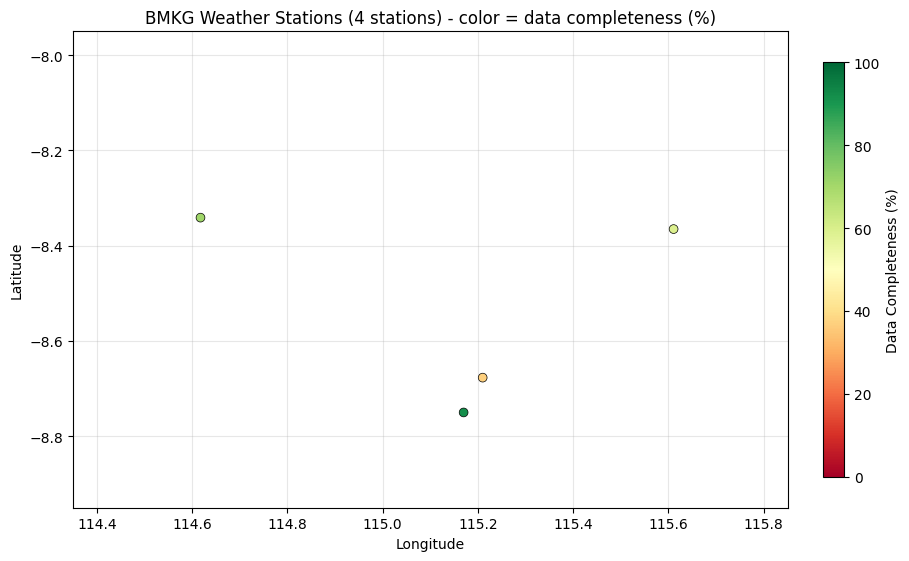

Stations with > 50% completeness: 3 / 4


In [8]:
"""
Step 4: Station location map with data completeness.
"""
# Calculate completeness per station
total_days = len(obs_df)
station_completeness = obs_df.notna().sum() / total_days * 100

# Match station locations with completeness
plot_data = station_df.copy()
plot_data['completeness'] = plot_data['ID_WMO'].astype(int).map(
    station_completeness.to_dict()
)
plot_data = plot_data.dropna(subset=['completeness'])

# Dynamic extent from config AOI (with pad), fallback to station coords
pad = float(getattr(config, 'MAP_EXTENT_PAD', 0.1))
aoi_lon = getattr(config, 'AOI_LON_RANGE', None)
aoi_lat = getattr(config, 'AOI_LAT_RANGE', None)
xlim = (aoi_lon[0] - pad, aoi_lon[1] + pad) if aoi_lon else (float(plot_data['Lon'].min()) - pad, float(plot_data['Lon'].max()) + pad)
ylim = (aoi_lat[0] - pad, aoi_lat[1] + pad) if aoi_lat else (float(plot_data['Lat'].min()) - pad, float(plot_data['Lat'].max()) + pad)
aspect = (xlim[1] - xlim[0]) / max(ylim[1] - ylim[0], 1e-6)

fig, ax = plt.subplots(figsize=(min(14, 6 * aspect), 6), constrained_layout=True)

sc = ax.scatter(
    plot_data['Lon'], plot_data['Lat'],
    c=plot_data['completeness'], cmap='RdYlGn',
    s=40, edgecolors='black', linewidths=0.5,
    vmin=0, vmax=100, zorder=5
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
title = f'BMKG Weather Stations ({len(plot_data)} stations) - color = data completeness (%)'
ax.set_title(title)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

cb = plt.colorbar(sc, ax=ax, shrink=0.7, label='Data Completeness (%)')

plt.show()

print(f"Stations with > 50% completeness: "
      f"{(plot_data['completeness'] > 50).sum()} / {len(plot_data)}")


### Step 5: Extract Gridded Values at Station Locations

For each gridded product, pull the time series at the nearest grid cell to each station with `xr.sel(method='nearest')`, building a paired observation-vs-prediction dataset.

::: {.callout-tip title="What you should see"}
The printed shapes should show one column per station and one row per day in the dekad window across all years. If a station's extracted series is entirely NaN, its coordinates fall on an ocean/masked pixel - check the location map in Step 4. Nearest-pixel extraction is a deliberate simplification; the docs note its limits for stations near coastlines.
:::


In [9]:
"""
Step 5: Extract gridded values at station locations for each product.
"""
from src.station_validation import extract_gridded_at_stations

extracted = {}
for method_name, gridded_da in gridded_products.items():
    print(f"Extracting {method_name} at station locations...")
    extracted[method_name] = extract_gridded_at_stations(gridded_da, station_df)
    print(f"  -> {extracted[method_name].shape[0]} timesteps x "
          f"{extracted[method_name].shape[1]} stations")

print(f"\nExtraction complete for {len(extracted)} products.")

Extracting LS at station locations...
2026-05-22 03:43:35,624 - INFO - Extracting gridded values at 4 station locations
2026-05-22 03:43:35,636 - INFO - Extracted 250 timesteps x 4 stations
  -> 250 timesteps x 4 stations
Extracting LSEQM at station locations...
2026-05-22 03:43:35,637 - INFO - Extracting gridded values at 4 station locations
2026-05-22 03:43:35,647 - INFO - Extracted 250 timesteps x 4 stations
  -> 250 timesteps x 4 stations
Extracting LSEQMDL at station locations...
2026-05-22 03:43:35,649 - INFO - Extracting gridded values at 4 station locations
2026-05-22 03:43:35,658 - INFO - Extracted 250 timesteps x 4 stations
  -> 250 timesteps x 4 stations
Extracting IMERG at station locations...
2026-05-22 03:43:35,659 - INFO - Extracting gridded values at 4 station locations
2026-05-22 03:43:36,701 - INFO - Extracted 9131 timesteps x 4 stations
  -> 9131 timesteps x 4 stations
Extracting CPC at station locations...
2026-05-22 03:43:36,703 - INFO - Extracting gridded values a

### Step 6: Compute Per-Station Metrics

For each product and station, compute the same 31 metrics used in the gridded evaluation (via `compute_pixel_metrics()`). Stations with fewer than 30 valid paired days are dropped, per WMO guidance.

::: {.callout-tip title="What you should see"}
Because Bali has only 4 stations, treat these as anecdotes, not statistics. The value here is *directional*: confirm that relative bias shrinks and the distribution metrics improve from LS to LSEQM. If a station is silently dropped, it failed the 30-day minimum - expected for sparse early-record stations.
:::


In [10]:
"""
Step 6: Compute per-station metrics for each product.
"""
from src.station_validation import compute_station_metrics

threshold = config.WET_DAY_THRESHOLD  # 1.0 mm/day
all_metrics = {}

for method_name, gridded_df in extracted.items():
    print(f"\n{'='*50}")
    print(f"Computing metrics: {method_name}")
    print(f"{'='*50}")

    metrics_df = compute_station_metrics(obs_df, gridded_df, threshold=threshold)
    all_metrics[method_name] = metrics_df

    if not metrics_df.empty:
        print(f"  Stations evaluated: {len(metrics_df)}")
        print(f"  Median valid days:  {metrics_df['n_valid_days'].median():.0f}")
        print(f"  Median corr:        {metrics_df['pearson_correlation'].median():.3f}")
        print(f"  Median NSE:         {metrics_df['nse'].median():.3f}")
        print(f"  Median RMSE:        {metrics_df['rmse'].median():.2f} mm/day")
        print(f"  Median rel. bias:   {metrics_df['relative_bias'].median():.3f}")
    else:
        print(f"  WARNING: No stations had sufficient data")

print(f"\nMetrics computed for {len(all_metrics)} products.")


Computing metrics: LS
2026-05-22 03:43:41,353 - INFO - Computing metrics for 4 common stations
2026-05-22 03:43:41,403 - INFO - Computed metrics for 4 stations
  Stations evaluated: 4
  Median valid days:  146
  Median corr:        0.399
  Median NSE:         -0.221
  Median RMSE:        22.48 mm/day
  Median rel. bias:   -0.051

Computing metrics: LSEQM
2026-05-22 03:43:41,404 - INFO - Computing metrics for 4 common stations
2026-05-22 03:43:41,438 - INFO - Computed metrics for 4 stations
  Stations evaluated: 4
  Median valid days:  146
  Median corr:        0.401
  Median NSE:         -0.224
  Median RMSE:        22.55 mm/day
  Median rel. bias:   0.023

Computing metrics: LSEQMDL
2026-05-22 03:43:41,440 - INFO - Computing metrics for 4 common stations
2026-05-22 03:43:41,471 - INFO - Computed metrics for 4 stations
  Stations evaluated: 4
  Median valid days:  146
  Median corr:        0.401
  Median NSE:         -0.223
  Median RMSE:        22.55 mm/day
  Median rel. bias:   0.02

### Step 6b: WMO Multi-Threshold Categorical Verification

The standard 31 metrics (Step 6) compute categorical scores only at the 1 mm wet-day
threshold. However, **skill at detecting moderate-to-extreme events** is often more
important for downstream applications (flood warning, water resource planning).

This step applies the WMO/TD-No. 1485 (WWRP 2009-1) multi-threshold verification
framework. For each station and each threshold, a 2x2 contingency table is built
and the following WMO-standard scores are computed:

| Score | Formula | Interpretation |
|-------|---------|----------------|
| **POD** | a/(a+c) | Fraction of observed events correctly detected |
| **FAR** | b/(a+b) | Fraction of predicted events that did not occur |
| **CSI** | a/(a+b+c) | Balanced accuracy excluding correct negatives |
| **FBI** | (a+b)/(a+c) | Frequency bias (>1 = overforecasting) |
| **ETS** | (a-a_r)/(a+b+c-a_r) | Skill relative to random chance |
| **HSS** | 2(ad-bc)/[...] | Fraction correct adjusted for chance |
| **HK** | POD-POFD | Ability to discriminate event from non-event |

**Thresholds** follow WMO/TD-No. 1485 Section 3.2 combined with
BMKG intensity classes: **1, 5, 10, 20, 50, 100, 150** mm/day.

Per WMO/TD-1485 guidance, scores are suppressed when fewer than 10 observed
events exist at a threshold.

In [11]:
"""
Step 6b: WMO multi-threshold categorical verification.

Computes POD, FAR, CSI, FBI, ETS, HSS, HK at thresholds
1, 5, 10, 20, 50, 100, 150 mm/day (WMO/TD-1485 + BMKG).
"""
from src.station_validation import (
    compute_multi_threshold_metrics,
    summarize_multi_threshold,
    WMO_THRESHOLDS,
    WMO_THRESHOLD_LABELS,
)

all_mt_metrics = {}
all_mt_summaries = {}

for method_name, gridded_df in extracted.items():
    print(f"\n{'='*60}")
    print(f"Multi-threshold verification: {method_name}")
    print(f"{'='*60}")

    mt_df = compute_multi_threshold_metrics(obs_df, gridded_df)
    all_mt_metrics[method_name] = mt_df

    if not mt_df.empty:
        mt_summary = summarize_multi_threshold(mt_df)
        all_mt_summaries[method_name] = mt_summary

        print(f"  Stations evaluated: {len(mt_df)}")
        print(f"\n  Threshold |  POD  |  FAR  |  CSI  |  FBI  |  ETS  |  HSS  |  HK   | Events")
        print(f"  {'-'*82}")
        for thr in WMO_THRESHOLDS:
            label = WMO_THRESHOLD_LABELS[thr]
            row = mt_summary.loc[thr] if thr in mt_summary.index else None
            if row is not None:
                print(f"  {thr:>4d} mm ({label:>11s}) | "
                      f"{row.get('pod_median', np.nan):5.3f} | "
                      f"{row.get('far_median', np.nan):5.3f} | "
                      f"{row.get('csi_median', np.nan):5.3f} | "
                      f"{row.get('fbi_median', np.nan):5.3f} | "
                      f"{row.get('ets_median', np.nan):5.3f} | "
                      f"{row.get('hss_median', np.nan):5.3f} | "
                      f"{row.get('hk_median', np.nan):5.3f} | "
                      f"{row.get('mean_obs_events', 0):6.0f}")
    else:
        print(f"  WARNING: No stations had sufficient data")

print(f"\nMulti-threshold verification complete for {len(all_mt_metrics)} products.")


Multi-threshold verification: LS
2026-05-22 03:43:45,777 - INFO - Computing multi-threshold metrics (7 thresholds) for 4 stations
2026-05-22 03:43:45,792 - INFO - Multi-threshold metrics computed for 4 stations
  Stations evaluated: 4

  Threshold |  POD  |  FAR  |  CSI  |  FBI  |  ETS  |  HSS  |  HK   | Events
  ----------------------------------------------------------------------------------
     1 mm ( measurable) | 0.819 | 0.179 | 0.702 | 1.056 | 0.181 | 0.300 | 0.314 |    101
     5 mm (      light) | 0.655 | 0.391 | 0.458 | 1.071 | 0.120 | 0.213 | 0.212 |     70
    10 mm (moderate_low) | 0.591 | 0.415 | 0.423 | 0.988 | 0.196 | 0.327 | 0.330 |     53
    20 mm (   moderate) | 0.312 | 0.631 | 0.204 | 0.912 | 0.097 | 0.175 | 0.166 |     32
    50 mm (      heavy) | 0.312 | 0.545 | 0.227 | 0.688 | 0.194 | 0.325 | 0.279 |      8
   100 mm ( very_heavy) |   nan |   nan |   nan |   nan |   nan |   nan |   nan |      2
   150 mm (    extreme) |   nan |   nan |   nan |   nan |   nan | 

### Step 6c: Extract Gridded Metrics and QA at Station Locations

Extract pixel-level metrics (from notebook 03 output) and QA categories/scores
(from notebook 04 output) at the nearest grid cell to each BMKG station.

This allows comparing what the gridded evaluation says about a station's location
versus what the independent station validation shows. Discrepancies can reveal
scale-dependent effects (0.1-degree grid cell vs. point measurement).

In [12]:
"""
Step 6c: Extract gridded metrics and QA at station locations.

Requires metrics/QA NetCDF files from notebooks 03 and 04.
Missing files are skipped gracefully.

Filename patterns (from notebooks 03/04):
  metrics: {prefix}_{prefix}_{ref}_{test}_month{MM}_dekad{DD}.nc4
  QA:      {prefix}_{prefix}_{ref}_{test}_month{MM}_dekad{DD}.nc4
  where prefix = metricssd|metricsts|qualitysd|qualityts
        ref = cpc|imergl|imergf
        test = imergl_ls|imergl_lseqm|imergl_lseqmdl
"""
from src.station_validation import extract_metrics_at_stations, extract_qa_at_stations

# Reference to use for station comparison (CPC is most relevant)
REF_LABEL = 'cpc'

# --- Extract gridded metrics (from notebook 03) ---
all_gridded_metrics = {}
for method_abbr in ['ls', 'lseqm', 'lseqmdl']:
    metrics_dir = config.metrics_path_template.replace('{method}', method_abbr)
    test_label = f"imergl_{method_abbr}"

    # Try single-dekad first, then timeseries
    for prefix in ['metricssd', 'metricsts']:
        fname = (f"{config.FILENAME_PREFIX}_{prefix}_{REF_LABEL}_{test_label}"
                 f"_month{month_str}_dekad{dekad_str}.nc4")
        fpath = os.path.join(metrics_dir, fname)
        df = extract_metrics_at_stations(fpath, station_df)
        if not df.empty:
            key = f"{method_abbr.upper()}_{prefix}"
            all_gridded_metrics[key] = df
            print(f"  Metrics {key}: {len(df)} stations, "
                  f"{len(df.columns)} variables")

# --- Extract gridded QA (from notebook 04) ---
all_gridded_qa = {}
for method_abbr in ['ls', 'lseqm', 'lseqmdl']:
    qa_dir = config.quality_path_template.replace('{method}', method_abbr)
    test_label = f"imergl_{method_abbr}"

    for prefix in ['qualitysd', 'qualityts']:
        fname = (f"{config.FILENAME_PREFIX}_{prefix}_{REF_LABEL}_{test_label}"
                 f"_month{month_str}_dekad{dekad_str}.nc4")
        fpath = os.path.join(qa_dir, fname)
        df = extract_qa_at_stations(fpath, station_df)
        if not df.empty:
            key = f"{method_abbr.upper()}_{prefix}"
            all_gridded_qa[key] = df
            print(f"  QA {key}: {len(df)} stations, {len(df.columns)} variables")

print(f"\nGridded metrics extracted: {list(all_gridded_metrics.keys())}")
print(f"Gridded QA extracted: {list(all_gridded_qa.keys())}")

# Display sample for LSEQMDL single-dekad
sample_key = 'LSEQMDL_metricssd'
if sample_key in all_gridded_metrics:
    print(f"\nSample gridded metrics at stations ({sample_key}):")
    sample_cols = ['pearson_correlation', 'relative_bias', 'rmse', 'nse', 'csi']
    avail = [c for c in sample_cols if c in all_gridded_metrics[sample_key].columns]
    if avail:
        display(all_gridded_metrics[sample_key][avail].describe().round(4))

2026-05-22 03:43:52,366 - INFO - Extracted 31 metrics at 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_ls/bali_cli_metricssd_cpc_imergl_ls_month01_dekad01.nc4


/content/drive/MyDrive/hybrid-bias-correction/src/station_validation.py:1100: FutureWarning: In a future version, xarray will not decode the variable 'dsl_ref' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(metrics_file, engine=NETCDF_ENGINE)
/content/drive/MyDrive/hybrid-bias-correction/src/station_validation.py:1100: FutureWarning: In a future version, xarray will not decode the variable 'dsl_test' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a tim

  Metrics LS_metricssd: 4 stations, 31 variables
2026-05-22 03:43:52,495 - INFO - Extracted 31 metrics at 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_ls/bali_cli_metricsts_cpc_imergl_ls_month01_dekad01.nc4
  Metrics LS_metricsts: 4 stations, 31 variables
2026-05-22 03:43:52,657 - INFO - Extracted 31 metrics at 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_lseqm/bali_cli_metricssd_cpc_imergl_lseqm_month01_dekad01.nc4
  Metrics LSEQM_metricssd: 4 stations, 31 variables


/content/drive/MyDrive/hybrid-bias-correction/src/station_validation.py:1100: FutureWarning: In a future version, xarray will not decode the variable 'dsl_ref' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(metrics_file, engine=NETCDF_ENGINE)
/content/drive/MyDrive/hybrid-bias-correction/src/station_validation.py:1100: FutureWarning: In a future version, xarray will not decode the variable 'dsl_test' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a tim

2026-05-22 03:43:52,797 - INFO - Extracted 31 metrics at 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_lseqm/bali_cli_metricsts_cpc_imergl_lseqm_month01_dekad01.nc4
  Metrics LSEQM_metricsts: 4 stations, 31 variables
2026-05-22 03:43:52,955 - INFO - Extracted 31 metrics at 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_lseqmdl/bali_cli_metricssd_cpc_imergl_lseqmdl_month01_dekad01.nc4
  Metrics LSEQMDL_metricssd: 4 stations, 31 variables


/content/drive/MyDrive/hybrid-bias-correction/src/station_validation.py:1100: FutureWarning: In a future version, xarray will not decode the variable 'dsl_ref' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(metrics_file, engine=NETCDF_ENGINE)
/content/drive/MyDrive/hybrid-bias-correction/src/station_validation.py:1100: FutureWarning: In a future version, xarray will not decode the variable 'dsl_test' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a tim

2026-05-22 03:43:53,091 - INFO - Extracted 31 metrics at 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_lseqmdl/bali_cli_metricsts_cpc_imergl_lseqmdl_month01_dekad01.nc4
  Metrics LSEQMDL_metricsts: 4 stations, 31 variables
2026-05-22 03:43:53,138 - INFO - Extracted 6 QA variables at 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_ls/bali_cli_qualitysd_cpc_imergl_ls_month01_dekad01.nc4
  QA LS_qualitysd: 4 stations, 6 variables
2026-05-22 03:43:53,214 - INFO - Extracted 6 QA variables at 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_ls/bali_cli_qualityts_cpc_imergl_ls_month01_dekad01.nc4
  QA LS_qualityts: 4 stations, 6 variables
2026-05-22 03:43:53,320 - INFO - Extracted 6 QA variables at 4 stations from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/quality_lseqm/bali_cli_qualitysd_cpc_imergl_lseqm_month01_dekad01.nc4


,pearson_correlation,relative_bias,rmse,nse,csi
count,4.0000,4.0000,4.0000,4.0000,4.0000
mean,0.6061,0.0435,14.2283,0.1445,0.7296
std,0.1364,0.0130,0.5565,0.2943,0.0329
min,0.4829,0.0274,13.4000,-0.2143,0.6916
25%,0.4931,0.0362,14.1739,-0.0326,0.7108
50%,0.5956,0.0448,14.4578,0.1812,0.7292
75%,0.7086,0.0521,14.5122,0.3583,0.7481
max,0.7503,0.0569,14.5975,0.4299,0.7685


### Step 7: Summary Comparison Table

Compare the median (and IQR) of key metrics across all correction methods, showing how each stage improves (or degrades) agreement with the independent stations.

::: {.callout-tip title="What you should see"}
For the 4-station Bali bundle, expect:

- **Pearson r** changes very little across stages (typically 0.20 to 0.35) - the [correlation ceiling](https://bennyistanto.github.io/hybrid-bias-correction/case-studies/indonesia.html#the-correlation-ceiling).
- **Relative bias** moves from negative (raw under-correction) through near-zero (LSEQM), and may overshoot slightly positive at LSEQM+DL.
- **CSI at 1 mm** drops a few percentage points from raw to corrected - the honest cost of suppressing over-detected drizzle (the [dry-day trade-off](https://bennyistanto.github.io/hybrid-bias-correction/methodology/eqm.html#wet-dry-handling)).
:::


In [13]:
"""
Step 7: Summary comparison table across methods.
"""
from src.station_validation import summarize_station_metrics

# Key metrics to highlight
key_metrics = [
    'pearson_correlation', 'relative_bias', 'rmse', 'mae', 'nse',
    'pod', 'far', 'csi', 'stdev_ratio', 'ks_pvalue'
]

# Build comparison table (median across stations for each method)
comparison_rows = []
for method_name, metrics_df in all_metrics.items():
    if metrics_df.empty:
        continue
    row = {'Method': method_name, 'N_stations': len(metrics_df)}
    for m in key_metrics:
        if m in metrics_df.columns:
            row[m] = metrics_df[m].median()
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('Method')

print("\n" + "="*70)
print("STATION VALIDATION: Median Metrics Across Methods")
print("="*70)
display(comparison_df.round(4))

# Also show full summary statistics for the best method
if 'LSEQMDL' in all_metrics and not all_metrics['LSEQMDL'].empty:
    print("\n" + "-"*70)
    print("Full Summary Statistics: LSEQMDL")
    print("-"*70)
    summary = summarize_station_metrics(all_metrics['LSEQMDL'])
    display(summary[key_metrics].round(4))


STATION VALIDATION: Median Metrics Across Methods


,N_stations,pearson_correlation,relative_bias,rmse,mae,nse,pod,far,csi,stdev_ratio,ks_pvalue
Method,,,,,,,,,,,
LS,4,0.3995,-0.0509,22.4848,12.9765,-0.2212,0.8185,0.1790,0.7024,0.9459,0.0118
LSEQM,4,0.4012,0.0228,22.5474,13.2474,-0.2235,0.8185,0.1790,0.7024,0.9260,0.2416
LSEQMDL,4,0.4014,0.0238,22.5474,13.2474,-0.2229,0.8185,0.1790,0.7024,0.9260,0.2416
IMERG,4,0.3362,-0.1763,16.4651,7.5916,-0.0882,0.6990,0.3427,0.4930,0.7728,0.0000
CPC,4,0.2826,-0.1786,16.9618,7.7614,-0.1038,0.6982,0.3362,0.4987,0.7730,0.0000



----------------------------------------------------------------------
Full Summary Statistics: LSEQMDL
----------------------------------------------------------------------


,pearson_correlation,relative_bias,rmse,mae,nse,pod,far,csi,stdev_ratio,ks_pvalue
count,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000
mean,0.3472,0.0062,21.5816,13.0452,-0.2372,0.8218,0.2052,0.6780,0.9454,0.2559
std,0.1513,0.0846,4.3823,2.7980,0.2368,0.0527,0.0789,0.0724,0.1171,0.1651
min,0.1277,-0.1015,15.4503,9.4290,-0.4714,0.7698,0.1440,0.5746,0.8260,0.1095
p25,0.3072,-0.0411,20.3912,12.2355,-0.4260,0.7817,0.1560,0.6548,0.8839,0.1178
median,0.4014,0.0238,22.5474,13.2474,-0.2229,0.8185,0.1790,0.7024,0.9260,0.2416
p75,0.4413,0.0711,23.7378,14.0571,-0.0341,0.8586,0.2282,0.7256,0.9875,0.3797
max,0.4582,0.0788,25.7812,16.2570,-0.0316,0.8804,0.3186,0.7326,1.1038,0.4308


### Step 8: Per-Station Scatter Plot (On-Demand)

Scatter of observed vs predicted daily precipitation for one station, one panel per method, annotated with r / NSE / RMSE / RB. Change `STATION_WMO_ID` and re-run to inspect a different station.

::: {.callout-tip title="What you should see"}
A good correction tightens the cloud toward the 1:1 line and lifts the heavy-rain points (top-right) that raw IMERG-L compresses. You will still see substantial scatter even after correction - that residual is the daily-timing error the method cannot remove. The same view, pre-rendered for all 4 stations, is in the [Station Validation tutorial](https://bennyistanto.github.io/hybrid-bias-correction/tutorials/station-validation.html).
:::


Available stations (4 total): [97230, 97232, 97234, 97236]

Generating scatter plot for station 97230...


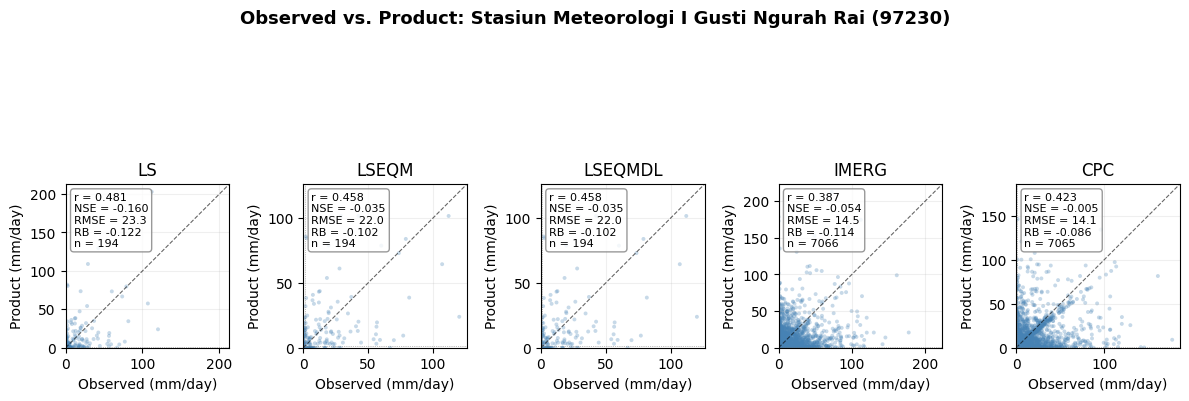

In [14]:
"""
Step 8: Per-station scatter plot.

Change STATION_WMO_ID and re-run this cell to inspect different stations.
"""
from src.station_validation import plot_station_scatter

# --- User input: which station to plot ---
STATION_WMO_ID = 97230  # <-- Change this to any valid WMO station ID

# List available stations for reference
available_stations = sorted(set(obs_df.columns) & set(list(extracted.values())[0].columns))
print(f"Available stations ({len(available_stations)} total): "
      f"{available_stations[:15]}{'...' if len(available_stations) > 15 else ''}")

# Check if requested station exists
if STATION_WMO_ID not in available_stations:
    print(f"\nStation {STATION_WMO_ID} not found in available stations.")
    print("Pick one from the list above.")
else:
    print(f"\nGenerating scatter plot for station {STATION_WMO_ID}...")
    fig = plot_station_scatter(
        obs_df, extracted, STATION_WMO_ID,
        station_df=station_df,
        threshold=config.WET_DAY_THRESHOLD,
    )

### Step 9: Per-Station Daily Precipitation Time Series (On-Demand)

Plot daily precipitation as **dots** (not lines) over time for a single station.
Each dataset is shown in a different color:
- **Black**: BMKG observed
- **Red**: LS corrected
- **Orange**: LSEQM corrected
- **Green**: LSEQMDL corrected

Horizontal dashed lines mark WMO rainfall intensity thresholds (5, 10, 20, 50, 100 mm/day)
for visual reference, following BMKG/WMO intensity classes.

**Usage**: Set `STATION_WMO_ID` below and re-run. Key metrics (r, RMSE, NSE) are
annotated for each product.

Available stations (4 total): [97230, 97232, 97234, 97236]

Generating time series plot for station 97230...


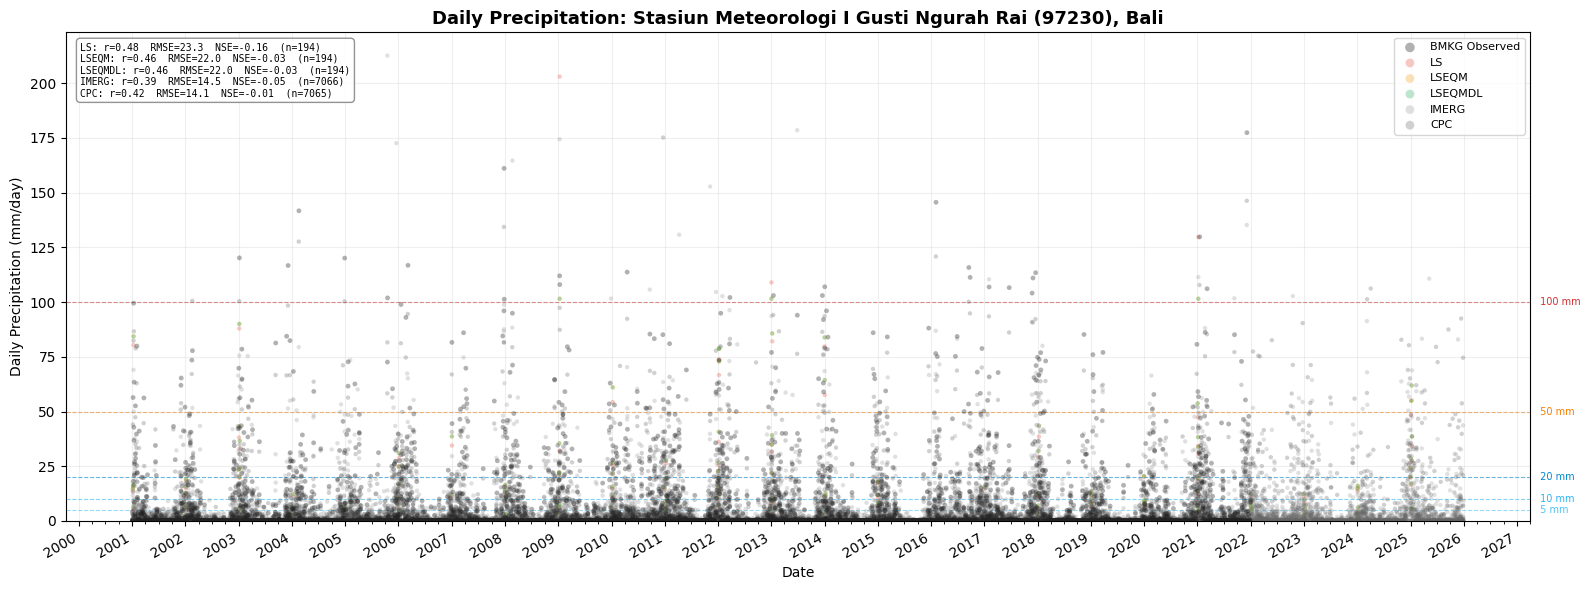

In [15]:
"""
Step 9: Per-station daily precipitation time series dot plot.

Change STATION_WMO_ID and re-run this cell to inspect different stations.
"""
from src.station_validation import plot_station_timeseries

# --- User input: which station to plot ---
STATION_WMO_ID = 97230  # <-- Change this to any valid WMO station ID

# List available stations for reference
available_stations = sorted(set(obs_df.columns) & set(list(extracted.values())[0].columns))
print(f"Available stations ({len(available_stations)} total): "
      f"{available_stations[:15]}{'...' if len(available_stations) > 15 else ''}")

# Check if requested station exists
if STATION_WMO_ID not in available_stations:
    print(f"\nStation {STATION_WMO_ID} not found in available stations.")
    print("Pick one from the list above.")
else:
    print(f"\nGenerating time series plot for station {STATION_WMO_ID}...")
    fig = plot_station_timeseries(
        obs_df, extracted, STATION_WMO_ID,
        station_df=station_df,
        thresholds=(5, 10, 20, 50, 100),
    )

### Step 10: Save Validation Results

Save per-station metrics as CSV files for each method, with station metadata
(name, coordinates, elevation) included.

In [16]:
"""
Step 10: Save validation results as CSV.

Saves:
  - Per-station 31-metric results (one CSV per method)
  - Per-station multi-threshold WMO metrics (one CSV per method)
  - Multi-threshold summary table (one CSV per method)
  - Cross-method comparison summary
"""
from src.station_validation import save_station_validation

output_dir = config.STATION_VALIDATION_OUTPUT_DIR
if output_dir is None:
    output_dir = os.path.join(config.output_dir, 'station_validation')

os.makedirs(output_dir, exist_ok=True)
saved_files = []

for method_name, metrics_df in all_metrics.items():
    if metrics_df.empty:
        print(f"  {method_name}: skipped (no data)")
        continue

    # --- 31-metric per-station results ---
    output_file = os.path.join(
        output_dir,
        f"station_validation_{method_name.lower()}_month{month_str}_dekad{dekad_str}.csv"
    )
    result = save_station_validation(
        metrics_df, station_df, output_file, method_name=method_name
    )
    if result:
        saved_files.append(result)
        print(f"  {method_name} (31-metric): saved -> {result}")

    # --- Multi-threshold per-station results ---
    if method_name in all_mt_metrics and not all_mt_metrics[method_name].empty:
        mt_file = os.path.join(
            output_dir,
            f"station_multi_threshold_{method_name.lower()}_month{month_str}_dekad{dekad_str}.csv"
        )
        mt_merged = all_mt_metrics[method_name].copy()
        # Merge station metadata
        loc_info = station_df[['ID_WMO', 'Station', 'Lon', 'Lat', 'Elevation']].copy()
        loc_info['ID_WMO'] = loc_info['ID_WMO'].astype(int)
        loc_info = loc_info.set_index('ID_WMO')
        mt_merged = mt_merged.join(loc_info, how='left')
        mt_merged.to_csv(mt_file, float_format='%.6f')
        saved_files.append(mt_file)
        print(f"  {method_name} (multi-thr): saved -> {mt_file}")

    # --- Multi-threshold summary ---
    if method_name in all_mt_summaries and not all_mt_summaries[method_name].empty:
        mt_sum_file = os.path.join(
            output_dir,
            f"multi_threshold_summary_{method_name.lower()}_month{month_str}_dekad{dekad_str}.csv"
        )
        all_mt_summaries[method_name].to_csv(mt_sum_file, float_format='%.6f')
        saved_files.append(mt_sum_file)
        print(f"  {method_name} (summary):   saved -> {mt_sum_file}")

# Cross-method comparison summary
if not comparison_df.empty:
    summary_file = os.path.join(
        output_dir,
        f"station_validation_summary_month{month_str}_dekad{dekad_str}.csv"
    )
    comparison_df.to_csv(summary_file, float_format='%.6f')
    saved_files.append(summary_file)
    print(f"  Summary: saved -> {summary_file}")

print(f"\nSaved {len(saved_files)} files to {output_dir}")

2026-05-22 03:44:24,508 - INFO - Saved station validation results (LS) to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_validation/station_validation_ls_month01_dekad01.csv
  LS (31-metric): saved -> /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_validation/station_validation_ls_month01_dekad01.csv
  LS (multi-thr): saved -> /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_validation/station_multi_threshold_ls_month01_dekad01.csv
  LS (summary):   saved -> /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_validation/multi_threshold_summary_ls_month01_dekad01.csv
2026-05-22 03:44:26,997 - INFO - Saved station validation results (LSEQM) to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_validation/station_validation_lseqm_month01_dekad01.csv
  LSEQM (31-metric): saved -> /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/o

---


## Summary

This notebook validated bias-corrected precipitation products (LS, LSEQM, LSEQM+DL)
against independent BMKG weather station observations for the selected month and dekad.

Key outputs:
- **Per-station 31-metric results** (continuous, categorical, distributional)
- **WMO multi-threshold verification** (POD, FAR, CSI, FBI, ETS, HSS, HK at 1/5/10/20/50/100/150 mm)
- **Regional and provincial summaries**
- **On-demand per-station scatter plots and time series**

All CSV outputs are saved to `data/output/station_validation/` and can be used
for further analysis in R, Excel, or other tools.

**Batch visualization** (spatial maps, multi-threshold curves, regional box plots)
has been moved to **notebook 06** where it runs alongside QA and Taylor diagram
batch visualization in a single unified batch cell.


---


## Batch Validation - All Months and Dekads

Run station validation for all 36 month/dekad combinations and save results.
This cell is self-contained: it loads data, computes metrics, and saves CSV
outputs for each period.

**Prerequisites** - run these cells before executing the batch:

| Cell | Purpose |
|------|---------|
| Step 1 | Environment setup, imports, `config` |
| Step 2 | Load station locations and observations |

Steps 3--10 are **not required** - the batch loop handles loading, extraction,
metric computation, and saving internally for each period.

In [ ]:
"""
Batch validation across all 36 month x dekad combinations.

For each period:
  1. Load corrected gridded products (LS, LSEQM, LSEQMDL)
  2. Extract at station locations
  3. Compute per-station 31 metrics + multi-threshold WMO metrics
  4. Save CSV outputs

Requires: Step 1 (setup) + Step 2 (station data loaded into obs_df, station_df).
"""
from src.station_validation import (
    extract_gridded_at_stations,
    compute_station_metrics,
    compute_multi_threshold_metrics,
    summarize_multi_threshold,
    save_station_validation,
    merge_station_metadata,
)

batch_output_dir = config.STATION_VALIDATION_OUTPUT_DIR
if batch_output_dir is None:
    batch_output_dir = os.path.join(config.output_dir, 'station_validation')
os.makedirs(batch_output_dir, exist_ok=True)

threshold = config.WET_DAY_THRESHOLD
n_done = 0
n_skip = 0

for _m in range(1, 13):
    for _d in [1, 2, 3]:
        _month_str = f"{_m:02d}"
        _dekad_str = '01' if _d == 1 else ('11' if _d == 2 else '21')
        tag = f"month {_month_str} dekad {_dekad_str}"
        print(f"  {tag}  ", end="")

        try:
            # --- Load corrected products for this period ---
            _methods = {
                'LS': config.ls_corrected_precip_path,
                'LSEQM': config.lseqm_corrected_precip_path,
                'LSEQMDL': config.lseqmdl_corrected_precip_path,
            }
            _products = {}
            for _mname, _folder in _methods.items():
                _abbr = _mname.lower()
                _fname = f"{config.FILENAME_PREFIX}_{_abbr}_corrected_imergl_month{_month_str}_dekad{_dekad_str}.nc4"
                _fpath = os.path.join(_folder, _fname)
                if os.path.exists(_fpath):
                    _ds = xr.open_dataset(_fpath)
                    _var = list(_ds.data_vars)[0]
                    _products[_mname] = _ds[_var]

            if not _products:
                print("no products found, skipping")
                n_skip += 1
                continue

            # --- Extract at stations ---
            _extracted = {}
            for _mname, _da in _products.items():
                _extracted[_mname] = extract_gridded_at_stations(_da, station_df)

            # --- Compute metrics + multi-threshold ---
            for _mname, _gdf in _extracted.items():
                _metrics = compute_station_metrics(obs_df, _gdf, threshold=threshold)
                if _metrics.empty:
                    continue

                # Save 31-metric CSV
                _out = os.path.join(
                    batch_output_dir,
                    f"station_validation_{_mname.lower()}_month{_month_str}_dekad{_dekad_str}.csv"
                )
                save_station_validation(_metrics, station_df, _out, method_name=_mname)

                # Multi-threshold CSV
                _mt = compute_multi_threshold_metrics(obs_df, _gdf)
                if not _mt.empty:
                    _mt_out = os.path.join(
                        batch_output_dir,
                        f"station_multi_threshold_{_mname.lower()}_month{_month_str}_dekad{_dekad_str}.csv"
                    )
                    _loc = station_df[['ID_WMO', 'Station', 'Lon', 'Lat', 'Elevation']].copy()
                    _loc['ID_WMO'] = _loc['ID_WMO'].astype(int)
                    _loc = _loc.set_index('ID_WMO')
                    _mt.join(_loc, how='left').to_csv(_mt_out, float_format='%.6f')

                    # Summary CSV
                    _mt_sum = summarize_multi_threshold(_mt)
                    if not _mt_sum.empty:
                        _sum_out = os.path.join(
                            batch_output_dir,
                            f"multi_threshold_summary_{_mname.lower()}_month{_month_str}_dekad{_dekad_str}.csv"
                        )
                        _mt_sum.to_csv(_sum_out, float_format='%.6f')

            # Close datasets
            for _da in _products.values():
                if hasattr(_da, 'close'):
                    _da.close()

            n_done += 1
            print("done")

        except Exception as e:
            n_skip += 1
            print(f"FAILED: {e}")

print(f"\nBatch complete: {n_done} done, {n_skip} skipped out of 36 periods.")
print(f"Output directory: {batch_output_dir}")

  month 01 dekad 01  2026-05-20 08:41:50,037 - INFO - Extracting gridded values at 4 station locations
2026-05-20 08:41:50,050 - INFO - Extracted 250 timesteps x 4 stations
2026-05-20 08:41:50,051 - INFO - Extracting gridded values at 4 station locations
2026-05-20 08:41:50,061 - INFO - Extracted 250 timesteps x 4 stations
2026-05-20 08:41:50,063 - INFO - Extracting gridded values at 4 station locations
2026-05-20 08:41:50,073 - INFO - Extracted 250 timesteps x 4 stations
2026-05-20 08:41:50,073 - INFO - Computing metrics for 4 common stations
2026-05-20 08:41:50,108 - INFO - Computed metrics for 4 stations
2026-05-20 08:41:50,237 - INFO - Saved station validation results (LS) to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/station_validation/station_validation_ls_month01_dekad01.csv
2026-05-20 08:41:50,239 - INFO - Computing multi-threshold metrics (7 thresholds) for 4 stations
2026-05-20 08:41:50,258 - INFO - Multi-threshold metrics computed for 4 stations
2

---

## End of Code